# PageIndex — Vectorless RAG
**No Vector DB. No Chunking. LLM reasons over document structure.**

Uses only: `groq` (free) + `PyPDF2` — nothing else needed.

📊 Diagram 1 — Traditional RAG   

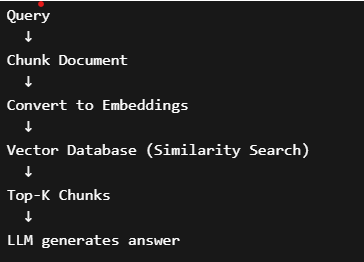

📊 Diagram 2 — Vectorless RAG   

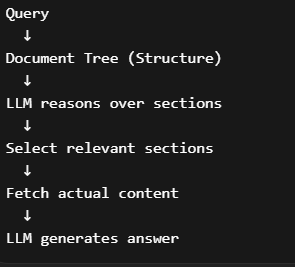

the document looks like this internally:

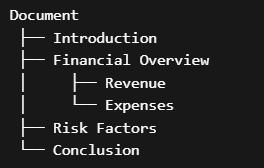

## Step 1 — Install

In [9]:
!pip install -q groq PyPDF2 python-dotenv

## Step 2 — Setup

In [17]:
import os, json
import PyPDF2
from groq import Groq
from dotenv import load_dotenv

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY", "").strip()
GROQ_MODEL   = "llama-3.3-70b-versatile"
client       = Groq(api_key=GROQ_API_KEY)

print("Groq:", "OK" if GROQ_API_KEY else "MISSING — add GROQ_API_KEY to .env")

Groq: OK


## Step 3 — Load PDF

In [19]:
PDF_PATH = "./Docs/2023-annual-report-truncated.pdf"   # change if needed

reader = PyPDF2.PdfReader(PDF_PATH)
pages  = [reader.pages[i].extract_text() or "" for i in range(len(reader.pages))]

print(f"PDF loaded: {len(pages)} pages")

PDF loaded: 50 pages


## Step 4 — Build Tree Index
LLM reads the PDF and builds a hierarchical structure (like a Table of Contents).

In [12]:
def build_tree(pages):
    # Send first 15 pages to LLM to detect structure
    sample = ""
    for i, text in enumerate(pages[:15], 1):
        sample += f"\n--- Page {i} ---\n{text[:800]}\n"

    prompt = f"""You are analyzing a document. Extract its section structure as a tree.

Document (first 15 pages):
{sample}

Return a JSON array. Each item has:
- node_id: zero-padded string like "0001"
- title: section name
- page_index: page number (integer)
- summary: one sentence about this section
- nodes: array of child sections (same structure, empty array if none)

Return ONLY valid JSON array, no extra text."""

    res = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    raw = res.choices[0].message.content.strip()
    # Clean markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1]
        raw = raw.rsplit("```", 1)[0]
    return json.loads(raw.strip())

print("Building tree... (takes ~10 seconds)")
tree = build_tree(pages)
print(f"Tree built: {len(tree)} top-level sections")

Building tree... (takes ~10 seconds)
Tree built: 1 top-level sections


## Step 5 — Inspect Tree

In [13]:
def print_tree(nodes, indent=0):
    for n in nodes:
        print("  " * indent + f"[{n['node_id']}] {n['title']}  (p.{n.get('page_index','?')})")
        if n.get("nodes"):
            print_tree(n["nodes"], indent + 1)

print("Document Structure:\n")
print_tree(tree)

Document Structure:

[0001] REPORT TO CONGRESS  (p.1)
  [0002] About the Federal Reserve  (p.5)
  [0003] Contents  (p.3)
    [0004] 1Overview  (p.7)
    [0005] 2Monetary Policy and Economic Developments  (p.9)
      [0006] March 2024 Summary  (p.9)
      [0007] June 2023 Summary  (p.15)
    [0008] 3Financial Stability  (p.15)


## Step 6 — Vectorless RAG Pipeline
```
1. LLM reads tree  →  picks relevant node IDs
2. Fetch pages     →  get actual content from PDF
3. LLM answers     →  cited answer from content
```

In [14]:
def llm_tree_search(query, tree):
    """LLM picks which section node_ids are relevant to the query."""
    def compress(nodes):
        return [{"node_id": n["node_id"], "title": n["title"],
                 "page": n.get("page_index", "?"),
                 "summary": n.get("summary", ""),
                 **(({"nodes": compress(n["nodes"])} if n.get("nodes") else {}))}
                for n in nodes]

    prompt = f"""Document tree (Table of Contents):
{json.dumps(compress(tree), indent=2)}

Query: {query}

Which node_ids contain the answer? Think step by step.
Reply ONLY in JSON: {{"thinking": "...", "node_list": ["0001", "0002"]}}"""

    res = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0
    )
    return json.loads(res.choices[0].message.content)


def get_node_content(tree, node_ids, pages):
    """Fetch page content for selected nodes."""
    def find(nodes):
        found = []
        for n in nodes:
            if n["node_id"] in node_ids:
                found.append(n)
            if n.get("nodes"):
                found.extend(find(n["nodes"]))
        return found

    nodes = find(tree)
    result = []
    for n in nodes:
        pg = n.get("page_index", 1)
        # Get content from that page (and next page)
        content = ""
        for p in range(max(0, pg - 1), min(len(pages), pg + 1)):
            content += pages[p]
        result.append({"title": n["title"], "page": pg, "text": content[:2000]})
    return result


def generate_answer(query, sections):
    """Generate cited answer from retrieved sections."""
    if not sections:
        return "No relevant sections found."
    context = "\n\n---\n\n".join(
        f"[{s['title']} | Page {s['page']}]\n{s['text']}" for s in sections
    )
    prompt = f"""Answer the question using ONLY the context. Cite section and page.

Question: {query}

Context:
{context}

Answer:"""
    res = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1
    )
    return res.choices[0].message.content


def vectorless_rag(query, tree, pages):
    """Full pipeline: tree search → retrieve → answer."""
    print(f"Query: {query}\n")

    search   = llm_tree_search(query, tree)
    node_ids = search.get("node_list", [])
    print(f"Reasoning: {search.get('thinking', '')[:200]}...")
    print(f"Selected nodes: {node_ids}\n")

    sections = get_node_content(tree, node_ids, pages)
    print(f"Sections found: {[s['title'] for s in sections]}\n")

    answer = generate_answer(query, sections)
    print("Answer:")
    print(answer)
    return answer


print("Pipeline ready.")

Pipeline ready.


## Step 7 — Ask a Question

In [15]:
answer = vectorless_rag(
    query="What are the key financial highlights of this report?",
    tree=tree,
    pages=pages
)

Query: What are the key financial highlights of this report?

Reasoning: To find the key financial highlights, we need to look for sections that discuss financial aspects. The node with title 'REPORT TO CONGRESS' is the main report, but it's too broad. The node 'About the ...
Selected nodes: ['0004', '0005', '0006', '0007', '0008']

Sections found: ['1Overview', '2Monetary Policy and Economic Developments', 'March 2024 Summary', 'June 2023 Summary', '3Financial Stability']

Answer:
The context does not provide a specific section that outlines the "key financial highlights" of the report. However, based on the information provided, some key financial highlights can be inferred from Section 2: Monetary Policy and Economic Developments (Pages 9-15) and Section 3: Financial Stability (Page 15).

Some key financial highlights mentioned in these sections include:

* Inflation remains above the Federal Open Market Committee's (FOMC) objective of 2 percent, but has eased substantially over the

In [16]:
# Try another query
answer = vectorless_rag(
    query="What are the main risks mentioned in this document?",
    tree=tree,
    pages=pages
)

Query: What are the main risks mentioned in this document?

Reasoning: To find the main risks mentioned in the document, we need to look for sections that discuss potential threats or instability. The section '3Financial Stability' seems relevant as it reviews activities...
Selected nodes: ['0005', '0006', '0007', '0008']

Sections found: ['2Monetary Policy and Economic Developments', 'March 2024 Summary', 'June 2023 Summary', '3Financial Stability']

Answer:
The main risks mentioned in this document are inflation risks. As stated on Page 9, "the Committee remains highly attentive to inflation risks and is acutely aware that high inflation imposes significant hardship, especially on those least able to meet the higher costs of essentials." (Section: [2Monetary Policy and Economic Developments | Page 9])
